In [35]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from binsreg import binsreg
from sklearn.linear_model import LinearRegression

In [2]:
data_path = Path(os.environ["DATA_PATH"])

In [19]:
df = gpd.read_file(data_path / "baldios.geojson").assign(
    urban_void_count=lambda df: df["urban_void_count"]
    .replace("No Disponible", np.nan)
    .astype(float),
)

In [212]:
temp = df.dropna(subset=["urban_void_count", "dust_index"]).query(
    "urban_void_count > 0",
)
X = temp["urban_void_count"].to_numpy().reshape(-1, 1)
y = temp["dust_index"].to_numpy()

model = LinearRegression()
model.fit(X, y)

LinearRegression()

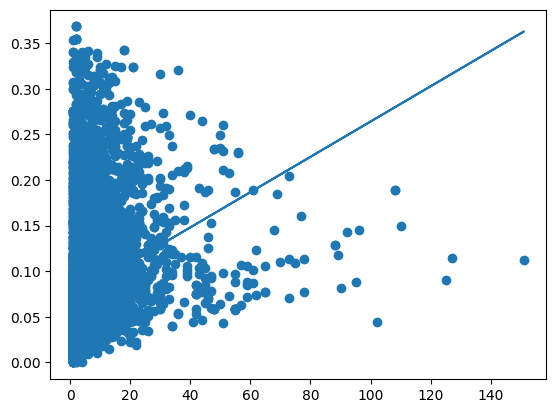

In [213]:
yhat = model.predict(X)

plt.scatter(X, y)
plt.plot(X, yhat)

In [214]:
rng = np.random.default_rng(42)
offset = rng.normal(0, 0.05, size=X.shape[0])
Xtest = X + offset.reshape(-1, 1)

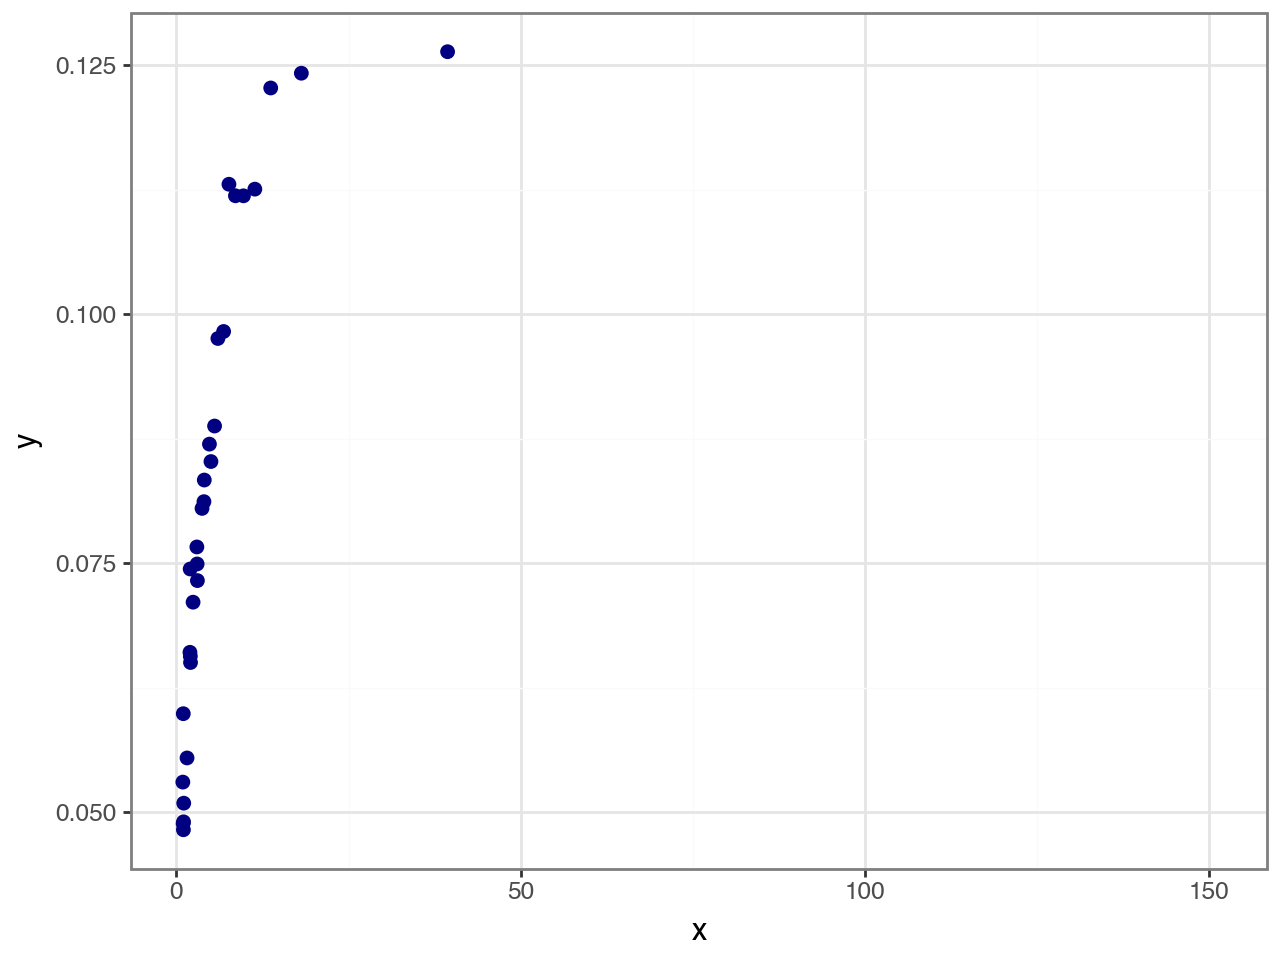

In [215]:
reg = binsreg(y, Xtest.flatten(), randcut=1, at="median")

In [232]:
df_reg = reg.data_plot[0].dots
df_reg = df_reg.assign(xlog=lambda df: df["x"].apply(lambda x: np.log10(x)))

In [251]:
df_reg

,group,x,bin,isknot,mid,fit,xlog
0,Full Sample,0.924751,0,0,0,0.053022,-0.033975
1,Full Sample,0.965289,1,0,0,0.048859,-0.015342
2,Full Sample,0.986992,2,0,0,0.059890,-0.005686
3,Full Sample,1.005443,3,0,0,0.048239,0.002358
4,Full Sample,1.024025,4,0,0,0.049033,0.010310
5,Full Sample,1.052369,5,0,0,0.050907,0.022168
6,Full Sample,1.531629,6,0,0,0.055447,0.185154
7,Full Sample,1.957447,7,0,0,0.066051,0.291690
8,Full Sample,1.987269,8,0,0,0.074415,0.298257
9,Full Sample,2.011678,9,0,0,0.065655,0.303558


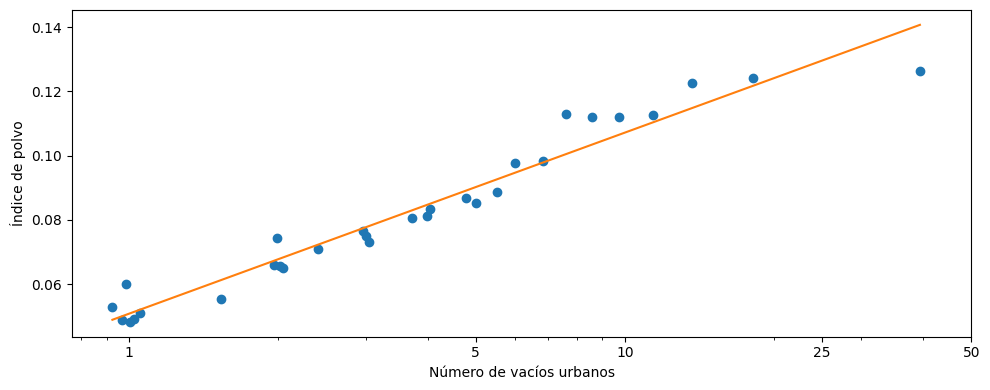

In [250]:
model = LinearRegression().fit(df_reg[["xlog"]], df_reg["fit"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xscale("log")
ax.scatter(df_reg["x"], df_reg["fit"], label="Binned averages", color="C0")
ax.plot(df_reg["x"], model.predict(df_reg[["xlog"]]), color="C1")
ax.set_xlabel("Número de vacíos urbanos")
ax.set_ylabel("Índice de polvo")

ax.set_xticks([1, 5, 10, 25, 50])
ax.set_xticklabels([1, 5, 10, 25, 50], rotation=0)

fig.tight_layout()